In [1]:
import pandas as pd 
import numpy as np

In [2]:
df = pd.read_csv("/Users/skush/CodeX/Stress-Level-Classifier/data/raw/Kaggle-stress-dataset-v2.csv")
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

In [3]:
df.shape

(5100, 16)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5100 entries, 0 to 5099
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   User_ID                  5100 non-null   object 
 1   Age                      4845 non-null   float64
 2   Gender                   5100 non-null   object 
 3   Occupation               5100 non-null   object 
 4   Sleep_Hours              4838 non-null   float64
 5   Daily_Screen_Hours       4848 non-null   float64
 6   Weekend_Screen_Hours     4846 non-null   float64
 7   Social_Media_Hours       4852 non-null   float64
 8   Caffeine_Cups_Per_Day    4825 non-null   float64
 9   Work_Productivity_Score  4832 non-null   float64
 10  App_Usage_Count          4864 non-null   float64
 11  Exercise_Hours_Per_Week  4888 non-null   float64
 12  Daily_Work_Hours         4845 non-null   float64
 13  Commute_Hours_Per_Day    4889 non-null   float64
 14  Stress_Level            

<h3> Formatting String Columns

In [6]:
string_cols = ['Gender', 'Occupation']

In [7]:
for str_col in string_cols :
    print(f" ======== {str_col} ========")
    print()
    print(f"Unique Values: {df[str_col].nunique() }")
    print()

 ======== Gender ========

Unique Values: 35

 ======== Occupation ========

Unique Values: 23



In [127]:
# Getting everythinf in lower case
for str_col in string_cols :
    df[str_col] = df[str_col].apply(lambda x : x.lower().strip())

In [133]:
df["Gender"].value_counts()

Gender
female    2062
male      1995
other     1043
Name: count, dtype: int64

In [129]:
df["Gender"] = df["Gender"].apply(lambda x : "male" if x.startswith("m") else "female" if x.startswith("f") else "other")

In [132]:
df["Occupation"].value_counts()

Occupation
student               988
retired               970
young professional    942
business owner        653
freelancer            541
teacher               525
healthcare worker     481
Name: count, dtype: int64

In [131]:
spelling_corrections = {"yng professional" : "young professional", "retried" : "retired", "studdent" : "student", "bussiness owner" : "business owner", "health care worker" : "healthcare worker", "techer" : "teacher", "free lancer" : "freelancer"}
df["Occupation"] = df["Occupation"].apply(lambda x: spelling_corrections[x] if x in spelling_corrections else x)

<h4> Outliers

In [135]:
df.columns

Index(['User_ID', 'Age', 'Gender', 'Occupation', 'Sleep_Hours',
       'Daily_Screen_Hours', 'Weekend_Screen_Hours', 'Social_Media_Hours',
       'Caffeine_Cups_Per_Day', 'Work_Productivity_Score', 'App_Usage_Count',
       'Exercise_Hours_Per_Week', 'Daily_Work_Hours', 'Commute_Hours_Per_Day',
       'Stress_Level', 'Stressed'],
      dtype='object')

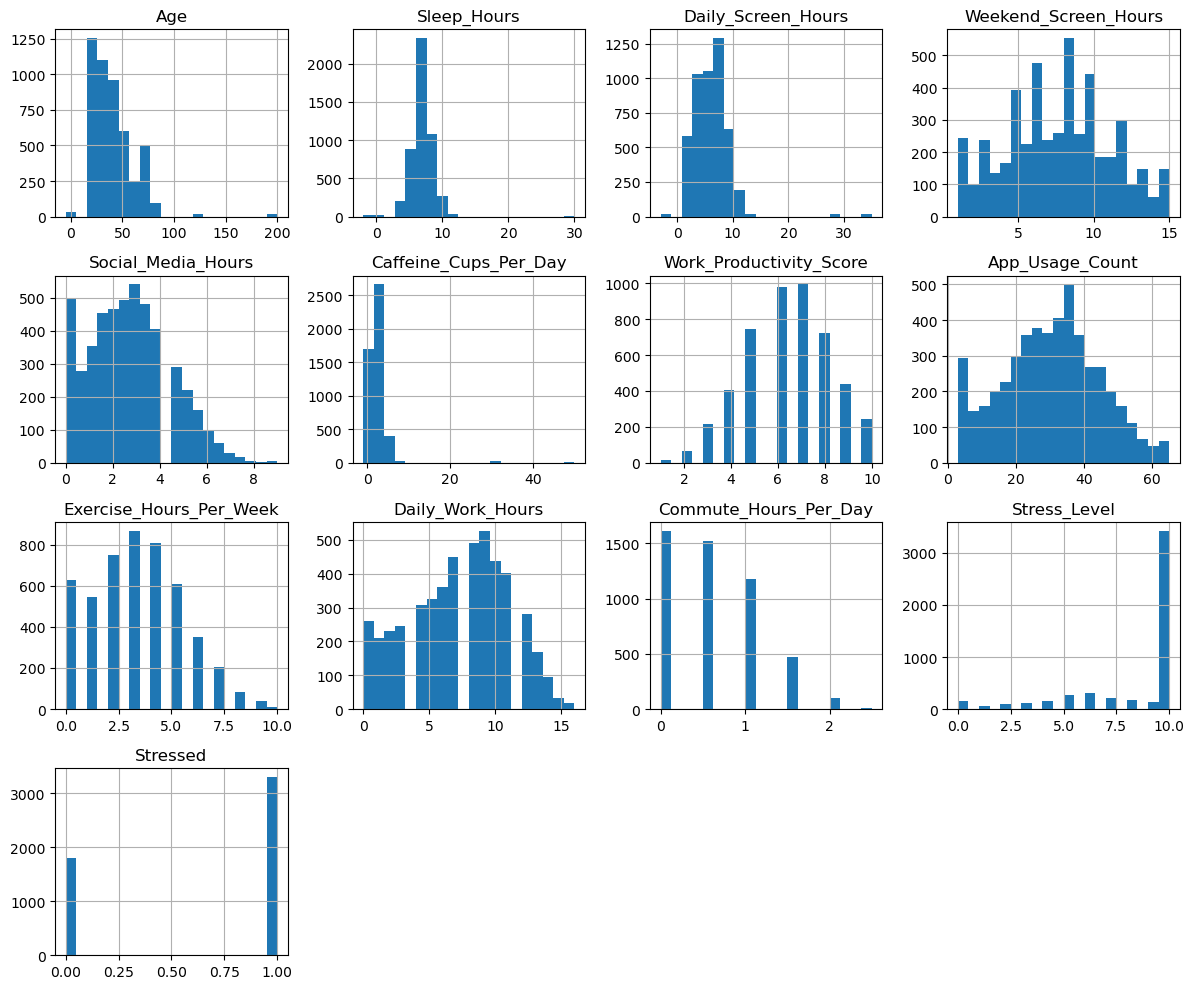

In [136]:
import seaborn as sns
import matplotlib.pyplot as plt

num_cols = df.select_dtypes(include=["int64", "float64"]).columns

df[num_cols].hist(figsize=(12,10), bins=20)

plt.tight_layout()
plt.show()

In [137]:
df = df[(~df["Age"].isna()) & (df["Age"] > 0) & (df["Age"] < 100)]
df = df[(df["Sleep_Hours"] > 0) & (df["Sleep_Hours"] < 24)]
df = df[(df["Daily_Screen_Hours"] > 0) & (df["Daily_Screen_Hours"] < 24)]
df = df[(df["Caffeine_Cups_Per_Day"] < 20)]


In [138]:
df.shape

(3975, 16)

<h3> Missing Values 

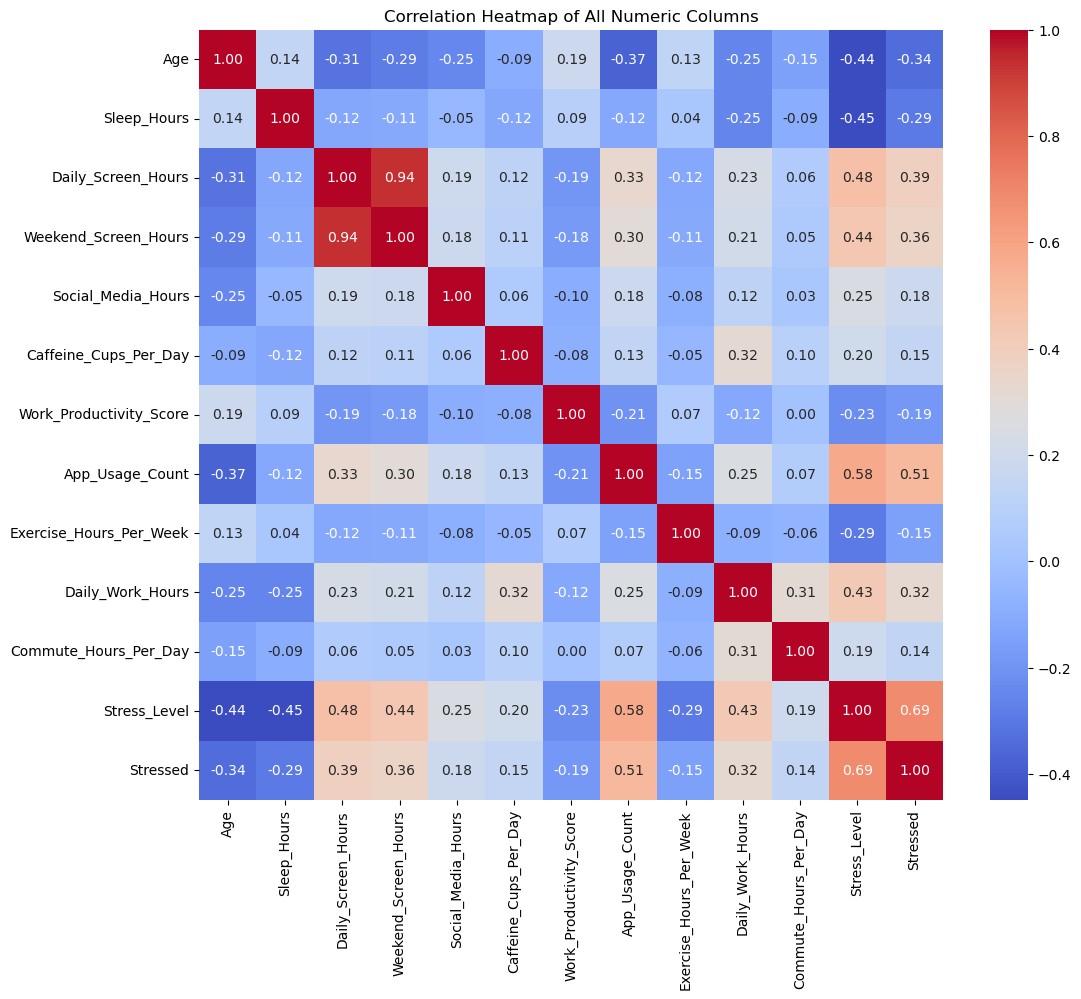

In [139]:
# Compute correlation matrix
corr_matrix = df.corr(numeric_only=True)

# Plot heatmap
plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Correlation Heatmap of All Numeric Columns")
plt.show()

In [166]:
df.isna().sum()

User_ID                    0
Age                        0
Gender                     0
Occupation                 0
Sleep_Hours                0
Daily_Screen_Hours         0
Weekend_Screen_Hours       0
Social_Media_Hours         0
Caffeine_Cups_Per_Day      0
Work_Productivity_Score    0
App_Usage_Count            0
Exercise_Hours_Per_Week    0
Daily_Work_Hours           0
Commute_Hours_Per_Day      0
Stress_Level               0
Stressed                   0
dtype: int64

<h5> Weekend Screen Hours 

In [141]:
df["Weekend_Screen_Hours"].corr(df["Daily_Screen_Hours"])

np.float64(0.9370338133639314)

In [142]:
daily_to_weekly_screen_ratio = df.loc[
    df["Weekend_Screen_Hours"].notna() & df["Daily_Screen_Hours"].notna(),
    "Weekend_Screen_Hours"
] / df.loc[
    df["Weekend_Screen_Hours"].notna() & df["Daily_Screen_Hours"].notna(),
    "Daily_Screen_Hours"
]

In [143]:
daily_to_weekly_screen_ratio.describe()

count    3782.000000
mean        1.309378
std         0.315079
min         0.285714
25%         1.142857
50%         1.297059
75%         1.444444
max         4.500000
dtype: float64

In [144]:
ratio = daily_to_weekly_screen_ratio.mean()

In [145]:
df.loc[df["Weekend_Screen_Hours"].isna(), "Weekend_Screen_Hours"] = (df["Daily_Screen_Hours"] * ratio)

<h4> Social_Media_Hours

In [146]:
df["Social_Media_Hours"].corr(df["Weekend_Screen_Hours"])

np.float64(0.1845126213404802)

In [147]:
social_to_weekly_screen_ratio = df.loc[
    df["Weekend_Screen_Hours"].notna() & df["Social_Media_Hours"].notna(),
    "Social_Media_Hours"
] / df.loc[
    df["Weekend_Screen_Hours"].notna() & df["Social_Media_Hours"].notna(),
    "Weekend_Screen_Hours"
]

In [148]:
social_to_weekly_screen_ratio.describe()

count    3784.000000
mean        0.463844
std         0.560786
min         0.000000
25%         0.181818
50%         0.333333
75%         0.545455
max         7.000000
dtype: float64

<b> HIgh Variability and low Correlation, we will simply impute with mean

In [149]:
mean_social_hours = df["Social_Media_Hours"].mean()
mean_social_hours

np.float64(2.66384778012685)

In [150]:
df["Social_Media_Hours"] = df["Social_Media_Hours"].fillna(mean_social_hours)

<h4> Work_Productivity_Score

In [151]:
median_productivity = df["Work_Productivity_Score"].median()
df["Work_Productivity_Score"] = df["Work_Productivity_Score"].fillna(median_productivity)

<h3> App_Usage_Count

In [152]:
train_df = df[["Age", "Daily_Screen_Hours", "Sleep_Hours", "Social_Media_Hours", "Exercise_Hours_Per_Week", "Work_Productivity_Score", "Daily_Work_Hours", "App_Usage_Count"]]
train_df.dropna(inplace=True)


/var/folders/1t/2nv4g8l96z74nfkrncg8x0br0000gn/T/ipykernel_2598/4151880582.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df.dropna(inplace=True)


In [153]:
train_df.head()

,Age,Daily_Screen_Hours,Sleep_Hours,Social_Media_Hours,Exercise_Hours_Per_Week,Work_Productivity_Score,Daily_Work_Hours,App_Usage_Count
0,27.0,3.0,5.0,3.0,6.0,8.0,11.0,31.0
1,28.0,5.5,5.0,3.0,7.0,7.0,10.0,25.0
2,29.0,7.0,5.5,2.5,4.0,4.0,11.0,28.0
3,28.0,3.5,9.0,3.5,1.0,5.0,14.0,34.0
5,20.0,5.0,8.0,4.0,4.0,6.0,5.0,50.0


In [154]:
from sklearn.linear_model import LinearRegression

regressor = LinearRegression()
x = train_df.drop(columns="App_Usage_Count")
regressor.fit(x, train_df["App_Usage_Count"])

LinearRegression()

In [155]:
mask = df["App_Usage_Count"].isna() & df[["Age","Daily_Screen_Hours","Sleep_Hours",
                                          "Social_Media_Hours","Exercise_Hours_Per_Week",
                                          "Work_Productivity_Score","Daily_Work_Hours"]].notna().all(axis=1)

In [156]:
df.loc[mask, "App_Usage_Count"] = regressor.predict(
    df.loc[mask, ["Age", "Daily_Screen_Hours", "Sleep_Hours", "Social_Media_Hours", 
                  "Exercise_Hours_Per_Week", "Work_Productivity_Score", "Daily_Work_Hours"]]
)

In [157]:
df = df.dropna(subset=["App_Usage_Count"])

<h4> Daily Work Hours

In [158]:
mean_weak_hours = df["Daily_Work_Hours"].mean()
mean_weak_hours

np.float64(7.138232953037941)

In [159]:
df["Daily_Work_Hours"] = df["Daily_Work_Hours"].fillna(mean_weak_hours)

<h4> Exercise_Hours_Per_Week

In [161]:
mean_exc_hours = df["Exercise_Hours_Per_Week"].mean()
mean_exc_hours

np.float64(3.1847368421052633)

In [162]:
df["Exercise_Hours_Per_Week"] = df["Exercise_Hours_Per_Week"].fillna(mean_exc_hours)

<h4> Commute_Hours_Per_Day

In [164]:
mean_commute_hours = df["Commute_Hours_Per_Day"].mean()
mean_commute_hours

np.float64(0.5827832057037232)

In [165]:
df["Commute_Hours_Per_Day"] = df["Commute_Hours_Per_Day"].fillna(mean_commute_hours)

In [167]:
df.to_csv("/Users/skush/CodeX/Stress-Level-Classifier/data/processed/cleaned_kaggle_v2.csv")

In [168]:
df.shape

(3957, 16)